# Финансовый бэк-тест: value-ставки и стратегии управления капиталом

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_DIR = Path(".")
OUTPUT_DIR = Path("value_backtest_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Конфигурация бэк-теста


In [ ]:
INITIAL_BANKROLL = 1000.0

DELTA_GRID = [0.00, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10]

FLAT_FRACTION = 0.01

FRACTIONAL_KELLY_COEFFICIENTS = [0.50, 0.25]

ONE_BET_PER_MATCH = True


USE_KELLY_CAP = False
KELLY_CAP = 0.05

MIN_STAKE = 1e-9
EPS = 1e-12

## 2. Загрузка прогнозов моделей


In [ ]:
PREDICTION_PATTERNS = [
    "predictions_dc_rolling_*.csv",
    "predictions_dc_ext_rolling_*.csv",
    "predictions_poisson_rolling_*.csv",
    "predictions_poisson_xg_*.csv",
    "predictions_*.csv",
]

COLUMN_ALIASES = {
    "p_home": ["p_home", "prob_home", "home_prob", "ph", "P_H", "model_home"],
    "p_draw": ["p_draw", "prob_draw", "draw_prob", "pd", "P_D", "model_draw"],
    "p_away": ["p_away", "prob_away", "away_prob", "pa", "P_A", "model_away"],

    "odds_home": ["odds_home", "B365H", "PSH", "AvgH", "MaxH", "home_odds", "odd_home"],
    "odds_draw": ["odds_draw", "B365D", "PSD", "AvgD", "MaxD", "draw_odds", "odd_draw"],
    "odds_away": ["odds_away", "B365A", "PSA", "AvgA", "MaxA", "away_odds", "odd_away"],

    "actual": ["actual", "FTR", "result", "outcome"],
}

def find_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    lower_to_original = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in df.columns:
            return name
        if name.lower() in lower_to_original:
            return lower_to_original[name.lower()]
    return None

def infer_model_and_league(filename: str) -> tuple[str, str]:
    stem = Path(filename).stem

    league_match = re.search(r"_(BL|EPL|SA|LA|LG1)(?:_|$)", stem)
    league = league_match.group(1) if league_match else "unknown"

    if "dc_ext" in stem:
        model = "Dixon-Coles extended"
    elif "dc_rolling" in stem or re.search(r"\bdc\b", stem):
        model = "Dixon-Coles"
    elif "poisson_xg" in stem:
        alpha_match = re.search(r"alpha([0-9.]+)", stem)
        alpha = alpha_match.group(1) if alpha_match else "unknown"
        model = f"Poisson xG blend α={alpha}"
    elif "poisson_rolling" in stem:
        model = "Poisson rolling"
    elif "poisson" in stem:
        model = "Poisson"
    else:
        model = stem

    return model, league

def normalize_prediction_df(raw: pd.DataFrame, source_file: str) -> pd.DataFrame:
    df = raw.copy()

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)
    else:
        df["Date"] = pd.NaT

    for col in ["HomeTeam", "AwayTeam"]:
        if col not in df.columns:
            df[col] = ""

    for target, aliases in COLUMN_ALIASES.items():
        source = find_existing_column(df, aliases)
        if source is not None and source != target:
            df[target] = df[source]

    required = ["p_home", "p_draw", "p_away", "odds_home", "odds_draw", "odds_away"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{source_file}: нет обязательных колонок {missing}")

    if "actual" not in df.columns:
        actual_source = find_existing_column(df, COLUMN_ALIASES["actual"])
        if actual_source is not None:
            df["actual"] = df[actual_source]
        elif {"FTHG", "FTAG"}.issubset(df.columns):
            df["actual"] = np.select(
                [df["FTHG"] > df["FTAG"], df["FTHG"] == df["FTAG"]],
                ["H", "D"],
                default="A"
            )
        else:
            raise ValueError(f"{source_file}: не найден actual/FTR или FTHG+FTAG")

    df["actual"] = (
        df["actual"]
        .astype(str)
        .str.upper()
        .str.strip()
        .replace({
            "HOME": "H", "1": "H", "П1": "H",
            "DRAW": "D", "X": "D", "НИЧЬЯ": "D",
            "AWAY": "A", "2": "A", "П2": "A",
        })
    )

    for col in required:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    model, league = infer_model_and_league(source_file)
    df["model"] = model
    df["league"] = league
    df["source_file"] = Path(source_file).name

    keep = [
        "Date", "HomeTeam", "AwayTeam", "actual",
        "p_home", "p_draw", "p_away",
        "odds_home", "odds_draw", "odds_away",
        "model", "league", "source_file"
    ]

    out = df[keep].dropna(subset=[
        "actual", "p_home", "p_draw", "p_away",
        "odds_home", "odds_draw", "odds_away"
    ]).copy()

    out = out[out["actual"].isin(["H", "D", "A"])]
    out = out[(out[["p_home", "p_draw", "p_away"]] >= 0).all(axis=1)]
    out = out[(out[["odds_home", "odds_draw", "odds_away"]] > 1).all(axis=1)]

    prob_sum = out[["p_home", "p_draw", "p_away"]].sum(axis=1)
    out = out[prob_sum > 0].copy()
    out[["p_home", "p_draw", "p_away"]] = out[["p_home", "p_draw", "p_away"]].div(prob_sum, axis=0)

    return out.reset_index(drop=True)

def load_prediction_files(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    files = []
    for pattern in PREDICTION_PATTERNS:
        files.extend(data_dir.glob(pattern))
    files = sorted(set(files))

    frames = []
    errors = []
    for f in files:
        try:
            raw = pd.read_csv(f)
            norm = normalize_prediction_df(raw, str(f))

            frames.append(norm)
            print(f"OK: {f.name} ({len(norm)} rows, model={norm['model'].iloc[0] if not norm.empty else 'empty'})")
        except Exception as e:
            errors.append((f.name, str(e)))
            print(f"SKIP: {f.name} -> {e}")


    if not frames:
        raise RuntimeError(f"Ошибки: {errors}")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values(["model", "league", "Date", "HomeTeam", "AwayTeam"]).reset_index(drop=True)
    return df

predictions = load_prediction_files(DATA_DIR)

print()
print("Загружено строк:", len(predictions))
display(predictions.head())
display(predictions.groupby(["model", "league", "source_file"]).size().reset_index(name="N"))


OK: predictions_dc_ext_rolling_BL.csv (298 rows, model=Dixon-Coles extended)
OK: predictions_dc_ext_rolling_EPL.csv (299 rows, model=Dixon-Coles extended)
OK: predictions_dc_ext_rolling_LA.csv (299 rows, model=Dixon-Coles extended)
OK: predictions_dc_ext_rolling_LG1.csv (298 rows, model=Dixon-Coles extended)
OK: predictions_dc_ext_rolling_SA.csv (299 rows, model=Dixon-Coles extended)
OK: predictions_dc_rolling_BL.csv (298 rows, model=Dixon-Coles)
OK: predictions_dc_rolling_EPL.csv (299 rows, model=Dixon-Coles)
OK: predictions_dc_rolling_LA.csv (299 rows, model=Dixon-Coles)
OK: predictions_dc_rolling_LG1.csv (298 rows, model=Dixon-Coles)
OK: predictions_dc_rolling_SA.csv (299 rows, model=Dixon-Coles)
OK: predictions_poisson_rolling_BL.csv (298 rows, model=Poisson rolling)
OK: predictions_poisson_rolling_EPL.csv (299 rows, model=Poisson rolling)
OK: predictions_poisson_rolling_LA.csv (299 rows, model=Poisson rolling)
OK: predictions_poisson_rolling_LG1.csv (298 rows, model=Poisson rollin

,Date,HomeTeam,AwayTeam,actual,p_home,p_draw,p_away,odds_home,odds_draw,odds_away,model,league,source_file
0,2025-03-29,Ein Frankfurt,Stuttgart,H,0.461889,0.259926,0.278184,2.50,3.80,2.50,Dixon-Coles,BL,predictions_dc_rolling_BL.csv
1,2025-03-30,Dortmund,Mainz,H,0.596430,0.223152,0.180417,1.62,3.90,5.00,Dixon-Coles,BL,predictions_dc_rolling_BL.csv
2,2025-03-30,Freiburg,Union Berlin,A,0.467747,0.296245,0.236008,2.00,3.50,3.70,Dixon-Coles,BL,predictions_dc_rolling_BL.csv
3,2025-04-04,Augsburg,Bayern Munich,A,0.130691,0.191451,0.677858,7.50,4.75,1.42,Dixon-Coles,BL,predictions_dc_rolling_BL.csv
4,2025-04-05,Bochum,Stuttgart,A,0.266352,0.265415,0.468233,3.10,3.70,2.15,Dixon-Coles,BL,predictions_dc_rolling_BL.csv


,model,league,source_file,N
0,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,298
1,Dixon-Coles,EPL,predictions_dc_rolling_EPL.csv,299
2,Dixon-Coles,LA,predictions_dc_rolling_LA.csv,299
3,Dixon-Coles,LG1,predictions_dc_rolling_LG1.csv,298
4,Dixon-Coles,SA,predictions_dc_rolling_SA.csv,299
5,Dixon-Coles extended,BL,predictions_dc_ext_rolling_BL.csv,298
6,Dixon-Coles extended,EPL,predictions_dc_ext_rolling_EPL.csv,299
7,Dixon-Coles extended,LA,predictions_dc_ext_rolling_LA.csv,299
8,Dixon-Coles extended,LG1,predictions_dc_ext_rolling_LG1.csv,298
9,Dixon-Coles extended,SA,predictions_dc_ext_rolling_SA.csv,299


## 3. Расчёт "честных" вероятностей и букмекерской маржи


In [4]:
def add_bookmaker_fair_probabilities(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["imp_home"] = 1 / out["odds_home"]
    out["imp_draw"] = 1 / out["odds_draw"]
    out["imp_away"] = 1 / out["odds_away"]

    out["overround"] = out["imp_home"] + out["imp_draw"] + out["imp_away"]
    out["margin"] = out["overround"] - 1

    out["fair_home"] = out["imp_home"] / out["overround"]
    out["fair_draw"] = out["imp_draw"] / out["overround"]
    out["fair_away"] = out["imp_away"] / out["overround"]

    return out

predictions_fair = add_bookmaker_fair_probabilities(predictions)

margin_summary = (
    predictions_fair
    .groupby(["model", "league"], as_index=False)
    .agg(
        N=("margin", "size"),
        avg_margin=("margin", "mean"),
        median_margin=("margin", "median"),
        min_margin=("margin", "min"),
        max_margin=("margin", "max"),
    )
)

display(margin_summary.round(4))
margin_summary.to_csv(OUTPUT_DIR / "bookmaker_margin_summary.csv", index=False)

,model,league,N,avg_margin,median_margin,min_margin,max_margin
0,Dixon-Coles,BL,298,0.0556,0.0549,0.0328,0.1102
1,Dixon-Coles,EPL,299,0.0552,0.0549,0.0386,0.1095
2,Dixon-Coles,LA,299,0.0563,0.0558,0.0404,0.1096
3,Dixon-Coles,LG1,298,0.0557,0.0556,0.0405,0.1229
4,Dixon-Coles,SA,299,0.0549,0.0549,0.0400,0.0750
5,Dixon-Coles extended,BL,298,0.0556,0.0549,0.0328,0.1102
6,Dixon-Coles extended,EPL,299,0.0552,0.0549,0.0386,0.1095
7,Dixon-Coles extended,LA,299,0.0563,0.0558,0.0404,0.1096
8,Dixon-Coles extended,LG1,298,0.0557,0.0556,0.0405,0.1229
9,Dixon-Coles extended,SA,299,0.0549,0.0549,0.0400,0.0750


## 4. Преобразование матчей в кандидаты на ставки

Одна строка исходной таблицы = один футбольный матч, но для ставок на рынок `1X2` один матч даёт три возможные ставки, поэтому надо развернуть каждый матч в три строки


In [5]:
OUTCOME_MAP = {
    "home": {"label": "H", "name": "П1"},
    "draw": {"label": "D", "name": "X"},
    "away": {"label": "A", "name": "П2"},
}

def make_bet_candidates(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for idx, row in df.reset_index(drop=True).iterrows():
        match_id = f"{row['source_file']}::{idx}"

        for outcome_key, meta in OUTCOME_MAP.items():
            label = meta["label"]
            rows.append({
                "match_id": match_id,
                "Date": row["Date"],
                "HomeTeam": row["HomeTeam"],
                "AwayTeam": row["AwayTeam"],
                "actual": row["actual"],
                "outcome": label,
                "outcome_name": meta["name"],
                "model": row["model"],
                "league": row["league"],
                "source_file": row["source_file"],
                "p_model": row[f"p_{outcome_key}"],
                "p_fair": row[f"fair_{outcome_key}"],
                "odds": row[f"odds_{outcome_key}"],
                "margin": row["margin"],
                "is_win": int(row["actual"] == label),
            })

    bets = pd.DataFrame(rows)
    bets["edge"] = bets["p_model"] - bets["p_fair"]
    bets["ev"] = bets["p_model"] * bets["odds"] - 1
    bets["fair_odds"] = 1 / bets["p_fair"]
    bets["model_fair_odds"] = 1 / bets["p_model"].clip(EPS, 1)

    return bets.sort_values(["model", "league", "Date", "match_id", "outcome"]).reset_index(drop=True)

candidates = make_bet_candidates(predictions_fair)

display(candidates.head(9))
display(
    candidates
    .groupby(["model", "league"])
    .agg(
        candidates=("edge", "size"),
        avg_edge=("edge", "mean"),
        max_edge=("edge", "max"),
        positive_edge_share=("edge", lambda x: (x > 0).mean()),
        positive_ev_share=("ev", lambda x: (x > 0).mean()),
    )
    .reset_index()
    .round(4)
)

candidates.to_csv(OUTPUT_DIR / "all_bet_candidates.csv", index=False)

,match_id,Date,HomeTeam,AwayTeam,actual,outcome,outcome_name,model,league,source_file,p_model,p_fair,odds,margin,is_win,edge,ev,fair_odds,model_fair_odds
0,predictions_dc_rolling_BL.csv::0,2025-03-29,Ein Frankfurt,Stuttgart,H,A,П2,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.278184,0.376238,2.50,0.063158,0,-0.098053,-0.304539,2.657895,3.594739
1,predictions_dc_rolling_BL.csv::0,2025-03-29,Ein Frankfurt,Stuttgart,H,D,X,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.259926,0.247525,3.80,0.063158,0,0.012402,-0.012280,4.040000,3.847244
2,predictions_dc_rolling_BL.csv::0,2025-03-29,Ein Frankfurt,Stuttgart,H,H,П1,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.461889,0.376238,2.50,0.063158,1,0.085652,0.154724,2.657895,2.165020
3,predictions_dc_rolling_BL.csv::1,2025-03-30,Dortmund,Mainz,H,A,П2,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.180417,0.186273,5.00,0.073694,0,-0.005855,-0.097913,5.368471,5.542702
4,predictions_dc_rolling_BL.csv::1,2025-03-30,Dortmund,Mainz,H,D,X,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.223152,0.238811,3.90,0.073694,0,-0.015659,-0.129706,4.187407,4.481243
5,predictions_dc_rolling_BL.csv::1,2025-03-30,Dortmund,Mainz,H,H,П1,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.596430,0.574916,1.62,0.073694,1,0.021514,-0.033783,1.739385,1.676642
6,predictions_dc_rolling_BL.csv::2,2025-03-30,Freiburg,Union Berlin,A,A,П2,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.236008,0.255941,3.70,0.055985,1,-0.019933,-0.126770,3.907143,4.237143
7,predictions_dc_rolling_BL.csv::2,2025-03-30,Freiburg,Union Berlin,A,D,X,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.296245,0.270567,3.50,0.055985,0,0.025678,0.036858,3.695946,3.375584
8,predictions_dc_rolling_BL.csv::2,2025-03-30,Freiburg,Union Berlin,A,H,П1,Dixon-Coles,BL,predictions_dc_rolling_BL.csv,0.467747,0.473492,2.00,0.055985,0,-0.005745,-0.064506,2.111969,2.137909


,model,league,candidates,avg_edge,max_edge,positive_edge_share,positive_ev_share
0,Dixon-Coles,BL,894,0.0,0.3062,0.5503,0.3982
1,Dixon-Coles,EPL,897,0.0,0.6673,0.4671,0.3501
2,Dixon-Coles,LA,897,0.0,0.3050,0.4749,0.3211
3,Dixon-Coles,LG1,894,0.0,0.2871,0.5089,0.3389
4,Dixon-Coles,SA,897,0.0,0.2432,0.4738,0.3322
5,Dixon-Coles extended,BL,894,0.0,0.3042,0.4676,0.3345
6,Dixon-Coles extended,EPL,897,0.0,0.6681,0.4693,0.3456
7,Dixon-Coles extended,LA,897,0.0,0.3046,0.4827,0.3278
8,Dixon-Coles extended,LG1,894,0.0,0.2849,0.4631,0.3322
9,Dixon-Coles extended,SA,897,0.0,0.2517,0.4671,0.3322


## 5. Отбор value-ставок по порогу delta

Условие отбора p_model - p_fair > delta

In [6]:
def select_value_bets(
    candidates: pd.DataFrame,
    delta: float,
    one_bet_per_match: bool = ONE_BET_PER_MATCH,
    require_positive_ev: bool = True,
) -> pd.DataFrame:
    selected = candidates[candidates["edge"] > delta].copy()

    if require_positive_ev:
        selected = selected[selected["ev"] > 0].copy()

    if selected.empty:
        return selected

    if one_bet_per_match:
        selected = (
            selected
            .sort_values(["model", "league", "match_id", "edge", "ev"], ascending=[True, True, True, False, False])
            .groupby(["model", "league", "match_id"], as_index=False)
            .head(1)
        )

    return selected.sort_values(["model", "league", "Date", "match_id"]).reset_index(drop=True)

selection_rows = []
for delta in DELTA_GRID:
    sel = select_value_bets(candidates, delta)
    if len(sel) == 0:
        continue
    tmp = (
        sel.groupby(["model", "league"], as_index=False)
        .agg(
            bets=("edge", "size"),
            avg_edge=("edge", "mean"),
            avg_ev=("ev", "mean"),
            avg_odds=("odds", "mean"),
            win_rate=("is_win", "mean"),
        )
    )
    tmp["delta"] = delta
    selection_rows.append(tmp)

selection_summary = pd.concat(selection_rows, ignore_index=True) if selection_rows else pd.DataFrame()
display(selection_summary.round(4))
selection_summary.to_csv(OUTPUT_DIR / "value_selection_summary.csv", index=False)

,model,league,bets,avg_edge,avg_ev,avg_odds,win_rate,delta
0,Dixon-Coles,BL,260,0.0580,0.1497,3.8377,0.2731,0.0
1,Dixon-Coles,EPL,259,0.0706,0.2070,3.8320,0.2741,0.0
2,Dixon-Coles,LA,243,0.0571,0.1392,3.8728,0.2840,0.0
3,Dixon-Coles,LG1,236,0.0687,0.1950,3.9151,0.3051,0.0
4,Dixon-Coles,SA,249,0.0587,0.1629,3.9487,0.2811,0.0
...,...,...,...,...,...,...,...,...
121,Poisson rolling,LG1,61,0.1437,0.4232,3.3390,0.3607,0.1
122,Poisson rolling,SA,35,0.1275,0.3825,3.3674,0.2286,0.1
123,Poisson xG blend α=0.0,BL,67,0.1498,0.3836,2.8509,0.2985,0.1
124,Poisson xG blend α=0.75,BL,39,0.1398,0.3688,2.9646,0.1538,0.1


## 6. Стратегии управления капиталом

### 6.1 Flat 

Flat -- на каждую выбранную value-ставку ставится фиксированная доля текущего размера банка

Преимущество: стратегия простая и не увеличивает риск. Недостаток: она не различает слабое и сильное преимущество.


### 6.2 Полный критерий Келли

Полный Келли рассчитывает оптимальную долю банка через вероятность модели.

Преимущество -- теоретически максимизирует логарифмический рост капитала. Недостаток -- в реальности приводит к более скорому проигрышу банка, если модель переоценивает вероятности.


### 6.3 Дробный критерий Келли

Дробный Келли берёт только часть от полного Kelly:

Преимущество -- так же увеличивает размер ставки, потенциально максимизируя рост капитала. Недостаток -- тот же, что и у полного критерия Келли.


In [ ]:
def kelly_fraction(p: float, odds: float) -> float:
    if odds <= 1:
        return 0.0
    f = (p * odds - 1) / (odds - 1)
    return max(0.0, float(f))

def stake_fraction_for_strategy(row: pd.Series, strategy: str) -> float:
    if strategy == "flat":
        return FLAT_FRACTION

    full_kelly = kelly_fraction(row["p_model"], row["odds"])

    if strategy == "kelly_full":
        f = full_kelly
    elif strategy.startswith("kelly_"):
        c = float(strategy.split("_")[1])
        f = c * full_kelly
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    if USE_KELLY_CAP:
        f = min(f, KELLY_CAP)

    return float(np.clip(f, 0.0, 1.0))

STRATEGIES = ["flat", "kelly_full"] + [f"kelly_{c}" for c in FRACTIONAL_KELLY_COEFFICIENTS]
STRATEGY_LABELS = {
    "flat": f"Flat betting ({FLAT_FRACTION:.1%} bankroll)",
    "kelly_full": "Full Kelly",
}
for c in FRACTIONAL_KELLY_COEFFICIENTS:
    STRATEGY_LABELS[f"kelly_{c}"] = f"Fractional Kelly ({c:g})"

STRATEGIES, STRATEGY_LABELS

(['flat', 'kelly_full', 'kelly_0.5', 'kelly_0.25'],
 {'flat': 'Flat betting (1.0% bankroll)',
  'kelly_full': 'Full Kelly',
  'kelly_0.5': 'Fractional Kelly (0.5)',
  'kelly_0.25': 'Fractional Kelly (0.25)'})

## 7. Бэк-тест стратегий

Имитируем проход по матчам в хронологическом порядке и делаем ставки только на те исходы, которые прошли value-фильтр.


In [8]:
def run_strategy_backtest(
    selected_bets: pd.DataFrame,
    strategy: str,
    initial_bankroll: float = INITIAL_BANKROLL,
) -> tuple[pd.DataFrame, dict]:
    if selected_bets.empty:
        empty_metrics = {
            "bets": 0,
            "final_bankroll": initial_bankroll,
            "profit": 0.0,
            "turnover": 0.0,
            "ROI": np.nan,
            "MDD": 0.0,
            "Sharpe": np.nan,
            "win_rate": np.nan,
            "avg_odds": np.nan,
            "avg_edge": np.nan,
            "avg_ev": np.nan,
        }
        return pd.DataFrame(), empty_metrics

    bets = selected_bets.sort_values(["Date", "match_id"]).reset_index(drop=True).copy()

    bankroll = float(initial_bankroll)
    peak = bankroll
    records = []

    for i, row in bets.iterrows():
        if bankroll <= 0:
            break

        f = stake_fraction_for_strategy(row, strategy)
        stake = bankroll * f

        if stake <= MIN_STAKE:
            continue

        if row["is_win"] == 1:
            profit = stake * (row["odds"] - 1)
        else:
            profit = -stake

        bankroll_after = bankroll + profit
        peak = max(peak, bankroll_after)
        drawdown = (peak - bankroll_after) / peak if peak > 0 else np.nan

        record = row.to_dict()
        record.update({
            "bet_no": len(records) + 1,
            "strategy": strategy,
            "strategy_label": STRATEGY_LABELS.get(strategy, strategy),
            "bankroll_before": bankroll,
            "stake_fraction": f,
            "stake": stake,
            "profit": profit,
            "bankroll_after": bankroll_after,
            "peak_bankroll": peak,
            "drawdown": drawdown,
            "return_on_stake": profit / stake if stake > 0 else np.nan,
        })
        records.append(record)

        bankroll = bankroll_after

    equity = pd.DataFrame(records)

    if equity.empty:
        return equity, {
            "bets": 0,
            "final_bankroll": initial_bankroll,
            "profit": 0.0,
            "turnover": 0.0,
            "ROI": np.nan,
            "MDD": 0.0,
            "Sharpe": np.nan,
            "win_rate": np.nan,
            "avg_odds": np.nan,
            "avg_edge": np.nan,
            "avg_ev": np.nan,
        }

    total_profit = equity["profit"].sum()
    turnover = equity["stake"].sum()
    returns = equity["return_on_stake"].replace([np.inf, -np.inf], np.nan).dropna()

    sharpe = np.nan
    if len(returns) > 1 and returns.std(ddof=1) > 0:
        sharpe = returns.mean() / returns.std(ddof=1)

    metrics = {
        "bets": int(len(equity)),
        "final_bankroll": float(equity["bankroll_after"].iloc[-1]),
        "profit": float(total_profit),
        "turnover": float(turnover),
        "ROI": float(total_profit / turnover) if turnover > 0 else np.nan,
        "MDD": float(equity["drawdown"].max()),
        "Sharpe": float(sharpe) if pd.notna(sharpe) else np.nan,
        "win_rate": float(equity["is_win"].mean()),
        "avg_odds": float(equity["odds"].mean()),
        "avg_edge": float(equity["edge"].mean()),
        "avg_ev": float(equity["ev"].mean()),
        "min_bankroll": float(equity["bankroll_after"].min()),
        "max_bankroll": float(equity["bankroll_after"].max()),
    }

    return equity, metrics

## 8. Комбинация: модели x лиги x delta x стратегии


In [ ]:
all_metrics = []
all_equity_curves = []

for (model, league), group in candidates.groupby(["model", "league"]):
    for delta in DELTA_GRID:
        selected = select_value_bets(group, delta)

        for strategy in STRATEGIES:
            equity, metrics = run_strategy_backtest(selected, strategy)

            row = {
                "model": model,
                "league": league,
                "delta": delta,
                "strategy": strategy,
                "strategy_label": STRATEGY_LABELS.get(strategy, strategy),
                **metrics,
            }
            all_metrics.append(row)

            if not equity.empty:
                equity["delta"] = delta
                all_equity_curves.append(equity)

metrics_df = pd.DataFrame(all_metrics)
equity_df = pd.concat(all_equity_curves, ignore_index=True) if all_equity_curves else pd.DataFrame()

for col in ["ROI", "MDD", "win_rate", "avg_edge", "avg_ev"]:
    if col in metrics_df.columns:
        metrics_df[f"{col}_pct"] = metrics_df[col] * 100

metrics_df = metrics_df.sort_values(["model", "league", "strategy", "delta"]).reset_index(drop=True)

display(metrics_df.round(4))

metrics_df.to_csv(OUTPUT_DIR / "value_backtest_metrics.csv", index=False)
if not equity_df.empty:
    equity_df.to_csv(OUTPUT_DIR / "value_backtest_equity_curves.csv", index=False)


,model,league,delta,strategy,strategy_label,bets,final_bankroll,profit,turnover,ROI,MDD,Sharpe,win_rate,avg_odds,avg_edge,avg_ev,min_bankroll,max_bankroll,ROI_pct,MDD_pct,win_rate_pct,avg_edge_pct,avg_ev_pct
0,Dixon-Coles,BL,0.00,flat,Flat betting (1.0% bankroll),260,551.0132,-448.9868,2057.3555,-0.2182,0.4749,-0.1459,0.2731,3.8377,0.0580,0.1497,539.1518,1026.7752,-21.8235,47.4908,27.3077,5.8001,14.9732
1,Dixon-Coles,BL,0.01,flat,Flat betting (1.0% bankroll),257,567.8798,-432.1202,2079.8340,-0.2078,0.4696,-0.1392,0.2763,3.8114,0.0586,0.1514,555.6554,1047.6229,-20.7767,46.9604,27.6265,5.8572,15.1366
2,Dixon-Coles,BL,0.02,flat,Flat betting (1.0% bankroll),234,613.1215,-386.8785,1938.3349,-0.1996,0.4329,-0.1318,0.2863,3.6699,0.0627,0.1631,599.9232,1057.9358,-19.9593,43.2930,28.6325,6.2708,16.3150
3,Dixon-Coles,BL,0.03,flat,Flat betting (1.0% bankroll),197,685.5472,-314.4528,1723.7422,-0.1824,0.3701,-0.1215,0.3046,3.5620,0.0699,0.1837,670.7898,1064.8522,-18.2425,37.0063,30.4569,6.9852,18.3728
4,Dixon-Coles,BL,0.05,flat,Flat betting (1.0% bankroll),123,785.4078,-214.5922,1192.7961,-0.1799,0.2787,-0.1147,0.2927,3.2898,0.0877,0.2284,785.4078,1088.9217,-17.9907,27.8729,29.2683,8.7654,22.8361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,Poisson xG blend α=1.0,BL,0.02,kelly_full,Full Kelly,235,0.3839,-999.6161,3799.7551,-0.2631,0.9998,-0.0956,0.3191,3.6237,0.0686,0.1775,0.3435,1576.9701,-26.3074,99.9782,31.9149,6.8580,17.7506
500,Poisson xG blend α=1.0,BL,0.03,kelly_full,Full Kelly,203,0.4202,-999.5798,3243.3223,-0.3082,0.9998,-0.1103,0.3202,3.4677,0.0753,0.1945,0.3760,1508.6585,-30.8196,99.9751,32.0197,7.5289,19.4466
501,Poisson xG blend α=1.0,BL,0.05,kelly_full,Full Kelly,145,0.2765,-999.7235,2566.3786,-0.3895,0.9998,-0.2772,0.2966,3.2180,0.0897,0.2299,0.2474,1445.9040,-38.9546,99.9829,29.6552,8.9670,22.9875
502,Poisson xG blend α=1.0,BL,0.07,kelly_full,Full Kelly,90,0.8028,-999.1972,2139.6156,-0.4670,0.9994,-0.3187,0.2889,3.1257,0.1086,0.2820,0.8028,1272.8721,-46.6998,99.9369,28.8889,10.8638,28.2035


## 9.1 Лучшие конфигурации по ROI

In [10]:
MIN_BETS_FOR_RANKING = 20

ranked_roi = (
    metrics_df[metrics_df["bets"] >= MIN_BETS_FOR_RANKING]
    .sort_values(["ROI", "MDD"], ascending=[False, True])
    .copy()
)

cols = [
    "model", "league", "delta", "strategy_label",
    "bets", "final_bankroll", "profit", "turnover",
    "ROI_pct", "MDD_pct", "Sharpe", "win_rate_pct",
    "avg_odds", "avg_edge_pct", "avg_ev_pct",
]

display(ranked_roi[cols].head(20).round(3))
ranked_roi[cols].to_csv(OUTPUT_DIR / "best_configs_by_roi.csv", index=False)

,model,league,delta,strategy_label,bets,final_bankroll,profit,turnover,ROI_pct,MDD_pct,Sharpe,win_rate_pct,avg_odds,avg_edge_pct,avg_ev_pct
369,Poisson rolling,LG1,0.07,Flat betting (1.0% bankroll),93,1176.319,176.319,1053.239,16.741,11.247,0.110,37.634,3.423,12.382,36.506
89,Dixon-Coles,LG1,0.07,Flat betting (1.0% bankroll),88,1160.193,160.193,972.965,16.464,10.351,0.106,37.500,3.421,12.077,35.357
229,Dixon-Coles extended,LG1,0.07,Flat betting (1.0% bankroll),94,1164.556,164.556,1058.387,15.548,11.247,0.103,37.234,3.477,12.400,36.963
368,Poisson rolling,LG1,0.05,Flat betting (1.0% bankroll),134,1189.689,189.689,1502.548,12.624,12.962,0.077,35.075,3.697,10.362,31.253
228,Dixon-Coles extended,LG1,0.05,Flat betting (1.0% bankroll),136,1190.159,190.159,1521.249,12.500,13.132,0.077,35.294,3.674,10.354,31.137
230,Dixon-Coles extended,LG1,0.10,Flat betting (1.0% bankroll),61,1081.139,81.139,658.488,12.322,11.502,0.082,36.066,3.339,14.458,42.608
370,Poisson rolling,LG1,0.10,Flat betting (1.0% bankroll),61,1081.139,81.139,658.488,12.322,11.502,0.082,36.066,3.339,14.374,42.324
90,Dixon-Coles,LG1,0.10,Flat betting (1.0% bankroll),51,1057.796,57.796,526.249,10.983,9.555,0.069,33.333,3.367,14.590,43.077
340,Poisson rolling,LA,0.05,Flat betting (1.0% bankroll),135,1153.406,153.406,1449.229,10.585,10.819,0.073,40.000,3.199,9.529,24.337
367,Poisson rolling,LG1,0.03,Flat betting (1.0% bankroll),199,1171.977,171.977,2143.064,8.025,15.238,0.053,34.673,3.700,8.287,24.148


## 9.2 Лучшие конфигурации по балансу доходности и риска


In [11]:
balanced = metrics_df[metrics_df["bets"] >= MIN_BETS_FOR_RANKING].copy()
balanced["risk_adjusted_score"] = balanced["ROI"] - balanced["MDD"]

balanced = balanced.sort_values(["risk_adjusted_score", "ROI"], ascending=[False, False])

display(
    balanced[
        cols + ["risk_adjusted_score"]
    ].head(20).round(3)
)

balanced[cols + ["risk_adjusted_score"]].to_csv(OUTPUT_DIR / "best_configs_balanced.csv", index=False)

,model,league,delta,strategy_label,bets,final_bankroll,profit,turnover,ROI_pct,MDD_pct,Sharpe,win_rate_pct,avg_odds,avg_edge_pct,avg_ev_pct,risk_adjusted_score
89,Dixon-Coles,LG1,0.07,Flat betting (1.0% bankroll),88,1160.193,160.193,972.965,16.464,10.351,0.106,37.500,3.421,12.077,35.357,0.061
369,Poisson rolling,LG1,0.07,Flat betting (1.0% bankroll),93,1176.319,176.319,1053.239,16.741,11.247,0.110,37.634,3.423,12.382,36.506,0.055
229,Dixon-Coles extended,LG1,0.07,Flat betting (1.0% bankroll),94,1164.556,164.556,1058.387,15.548,11.247,0.103,37.234,3.477,12.400,36.963,0.043
90,Dixon-Coles,LG1,0.10,Flat betting (1.0% bankroll),51,1057.796,57.796,526.249,10.983,9.555,0.069,33.333,3.367,14.590,43.077,0.014
230,Dixon-Coles extended,LG1,0.10,Flat betting (1.0% bankroll),61,1081.139,81.139,658.488,12.322,11.502,0.082,36.066,3.339,14.458,42.608,0.008
370,Poisson rolling,LG1,0.10,Flat betting (1.0% bankroll),61,1081.139,81.139,658.488,12.322,11.502,0.082,36.066,3.339,14.374,42.324,0.008
340,Poisson rolling,LA,0.05,Flat betting (1.0% bankroll),135,1153.406,153.406,1449.229,10.585,10.819,0.073,40.000,3.199,9.529,24.337,-0.002
368,Poisson rolling,LG1,0.05,Flat betting (1.0% bankroll),134,1189.689,189.689,1502.548,12.624,12.962,0.077,35.075,3.697,10.362,31.253,-0.003
228,Dixon-Coles extended,LG1,0.05,Flat betting (1.0% bankroll),136,1190.159,190.159,1521.249,12.500,13.132,0.077,35.294,3.674,10.354,31.137,-0.006
342,Poisson rolling,LA,0.10,Flat betting (1.0% bankroll),50,1025.028,25.028,494.843,5.058,6.606,0.039,38.000,3.043,13.991,36.538,-0.015


## 9.3 Сравнение стратегий

In [12]:
strategy_comparison = (
    metrics_df[metrics_df["bets"] >= MIN_BETS_FOR_RANKING]
    .groupby("strategy_label", as_index=False)
    .agg(
        configs=("strategy_label", "size"),
        avg_bets=("bets", "mean"),
        avg_ROI=("ROI", "mean"),
        median_ROI=("ROI", "median"),
        avg_MDD=("MDD", "mean"),
        median_MDD=("MDD", "median"),
        avg_Sharpe=("Sharpe", "mean"),
        positive_ROI_share=("ROI", lambda x: (x > 0).mean()),
    )
)

for c in ["avg_ROI", "median_ROI", "avg_MDD", "median_MDD", "positive_ROI_share"]:
    strategy_comparison[c + "_pct"] = strategy_comparison[c] * 100

display(strategy_comparison.round(3))
strategy_comparison.to_csv(OUTPUT_DIR / "strategy_comparison.csv", index=False)

,strategy_label,configs,avg_bets,avg_ROI,median_ROI,avg_MDD,median_MDD,avg_Sharpe,positive_ROI_share,avg_ROI_pct,median_ROI_pct,avg_MDD_pct,median_MDD_pct,positive_ROI_share_pct
0,Flat betting (1.0% bankroll),126,172.984,-0.150,-0.151,0.289,0.294,-0.12,0.119,-15.041,-15.134,28.910,29.385,11.905
1,Fractional Kelly (0.25),126,172.984,-0.213,-0.195,0.655,0.691,-0.12,0.119,-21.327,-19.536,65.521,69.086,11.905
2,Fractional Kelly (0.5),126,172.984,-0.244,-0.208,0.881,0.915,-0.12,0.000,-24.377,-20.756,88.090,91.454,0.000
3,Full Kelly,126,172.984,-0.340,-0.310,0.989,0.997,-0.12,0.000,-33.962,-31.021,98.878,99.734,0.000


## 10 Визуализация результатов: ROI vs MDD

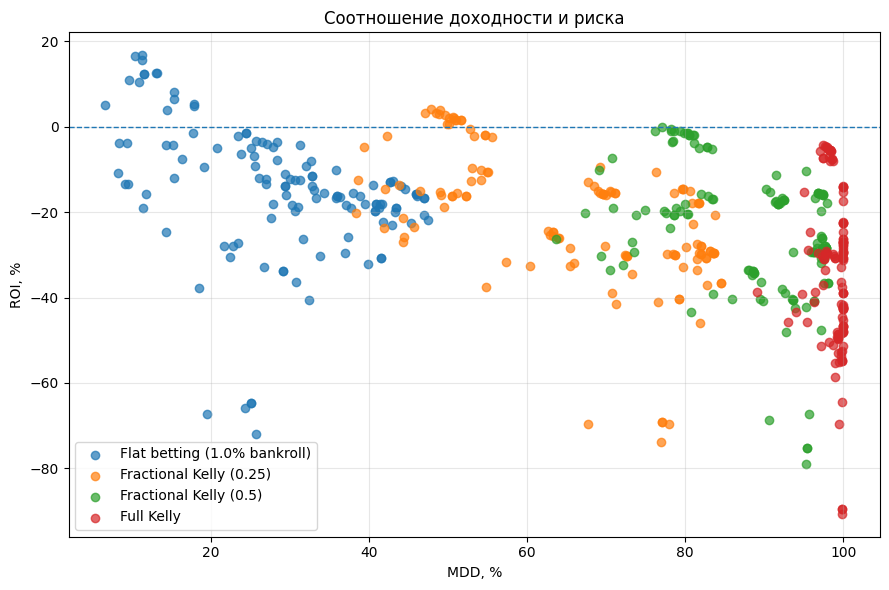

In [ ]:
scatter_df = metrics_df[metrics_df["bets"] >= MIN_BETS_FOR_RANKING].copy()

plt.figure(figsize=(9, 6))
for strategy_label, g in scatter_df.groupby("strategy_label"):
    plt.scatter(g["MDD"] * 100, g["ROI"] * 100, alpha=0.7, label=strategy_label)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("MDD, %")
plt.ylabel("ROI, %")
plt.title("Соотношение доходности и риска")
plt.grid(alpha=0.3)
plt.legend()